In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv(r"C:\Users\mahes\Downloads\Customer Churn.csv")

In [54]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# replacing blank with 0 as tenure is 0 and no total charges are recorded

In [21]:
df["TotalCharges"] = df["TotalCharges"].replace(" " , "0")
df["TotalCharges"] = df["TotalCharges"].astype("float")


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.isnull().sum().sum() # there is no null value in the dataset 

np.int64(0)

In [27]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [32]:
df["customerID"].duplicated().sum()

np.int64(0)

In [35]:
def conv(value): # converted o & 1 value of seinor citizen to yes/no to make it easier to understand 
    if value == 1:
        return "Yes"
    else:
        return "No"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


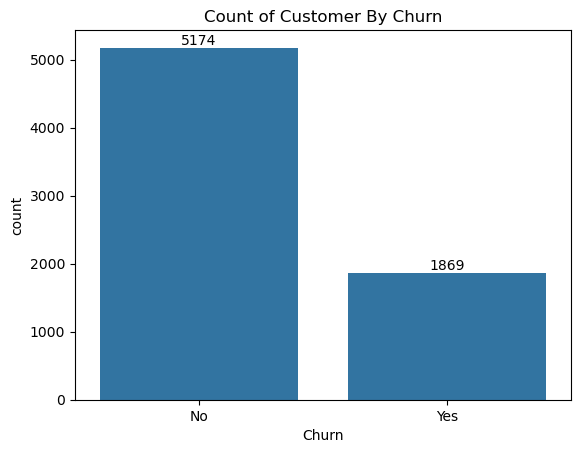

In [46]:
ax = sns.countplot(x = 'Churn' , data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customer By Churn")
plt.show()

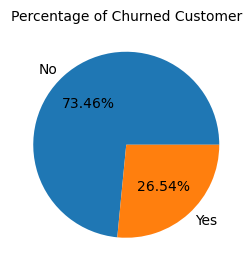

In [45]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'],labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customer", fontsize = 10)
plt.show()

# from the pie chart we can conclude that 26.54% of our customer have churned out. now lets explore the reason behind it

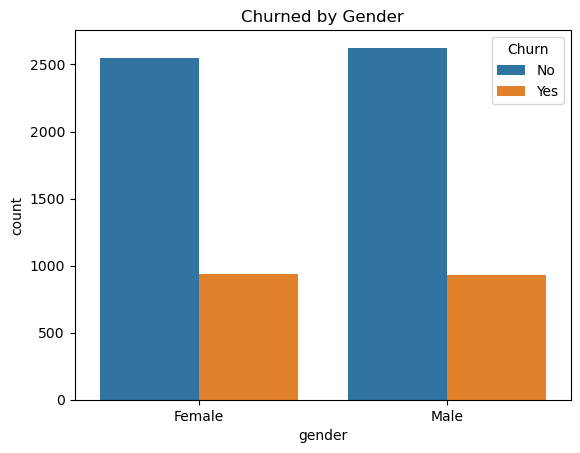

In [48]:
sns.countplot(x = "gender" , data = df , hue = "Churn")
plt.title("Churned by Gender")
plt.show()

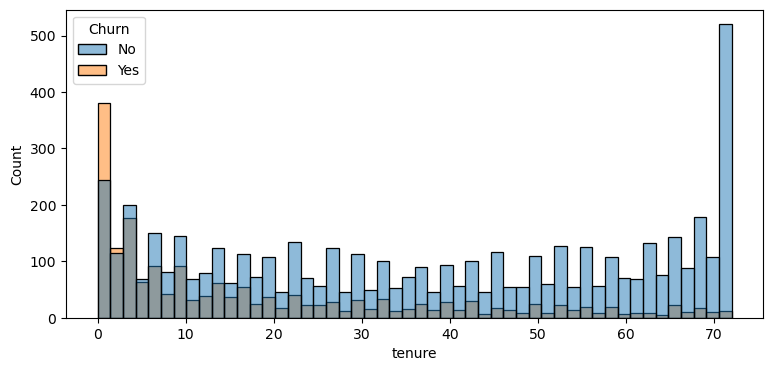

In [60]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df , bins = 50 , hue = "Churn")
plt.show()

# people who have used our services for long time have stayed and people who have used our services for 1 to 2 month have churned out 

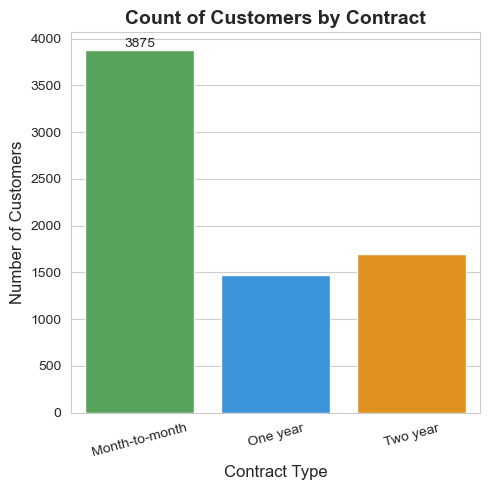

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,5))

sns.set_style("whitegrid")

colors = ["#4CAF50", "#2196F3", "#FF9800"]

ax = sns.countplot(x='Contract', data=df, hue = 'Contract', palette=colors)

ax.bar_label(ax.containers[0])

plt.title("Count of Customers by Contract", fontsize=14, fontweight='bold')
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [74]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

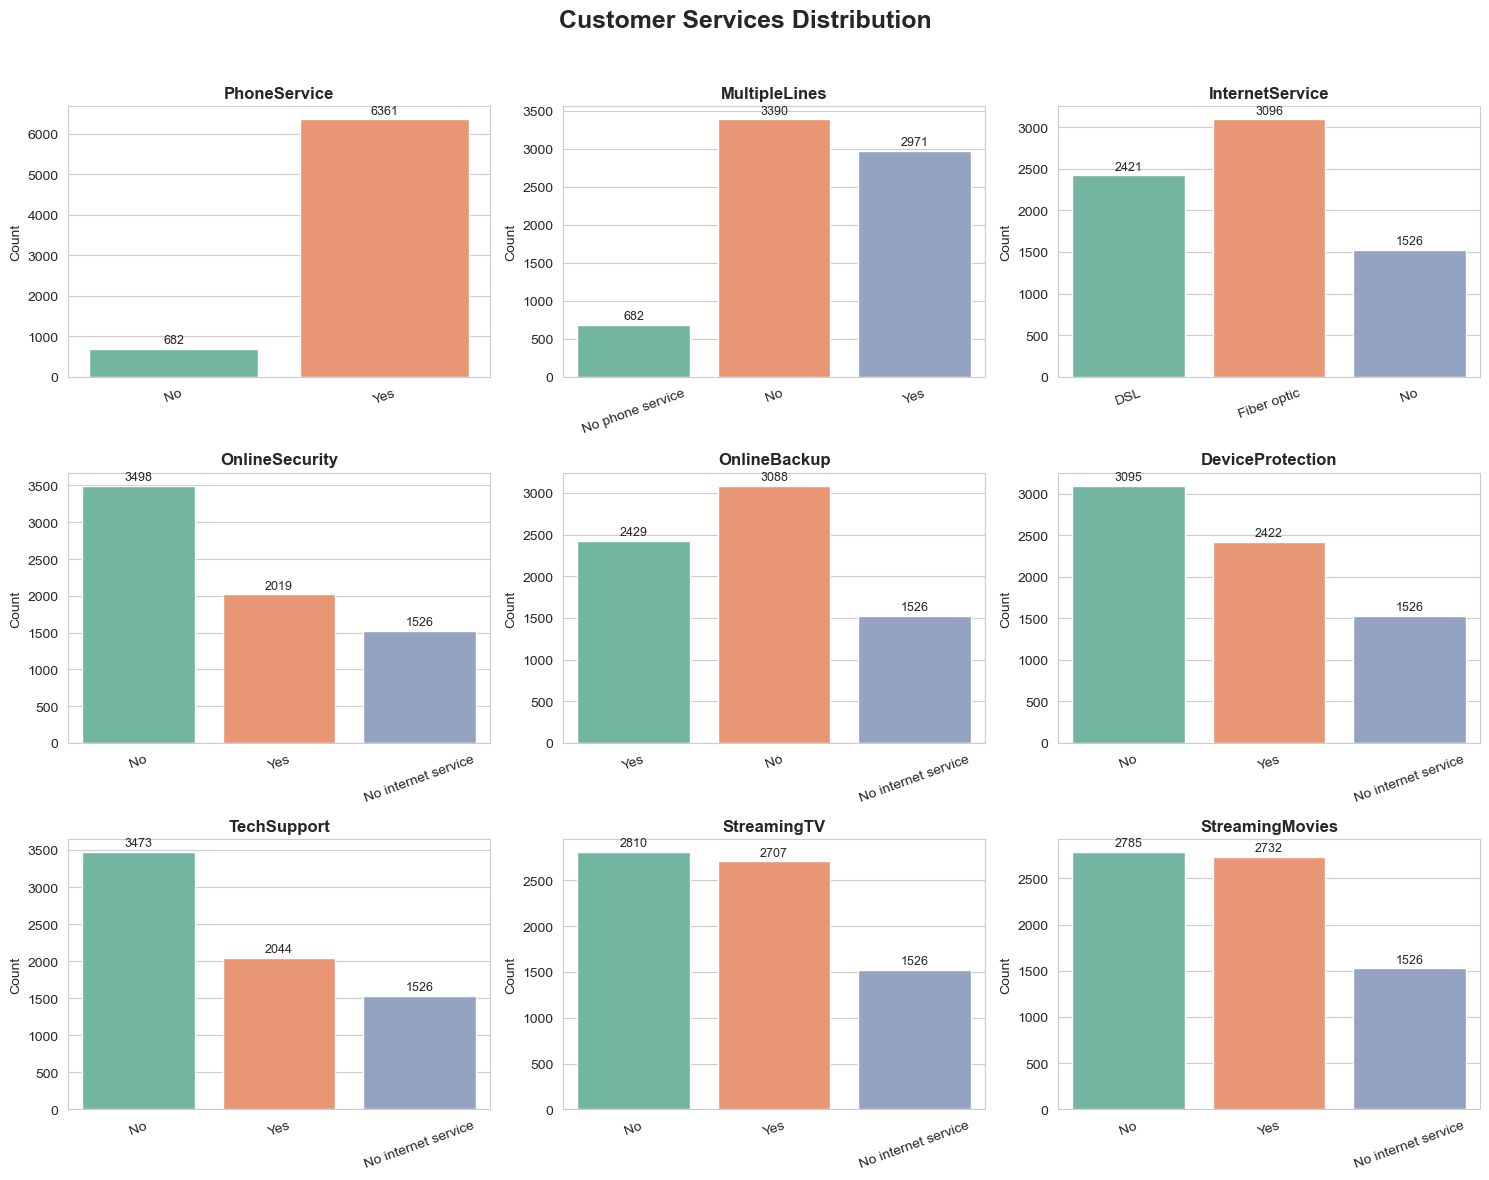

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is already defined in your environment
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

sns.set_style("whitegrid")

# Create the 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Select the current axis
    ax = axes[i]
    
    # Corrected sns.countplot call:
    # We pass the column name to 'x' and the dataframe to 'data'
    # 'hue=col' ensures the palette applies correctly without warnings
    sns.countplot(data=df, x=col, ax=ax, palette="Set2", hue=col, legend=False)
    
    # Add bar labels safely
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=9)
    
    # Formatting
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=20)

# Remove any unused subplots (if cols < 9)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Customer Services Distribution", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

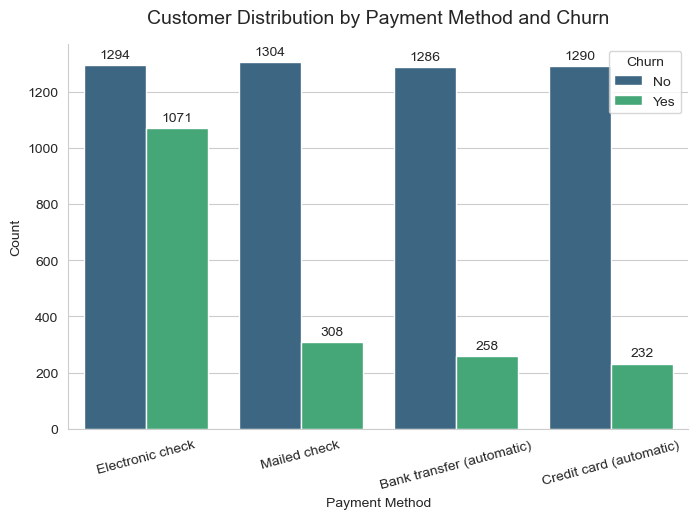

In [81]:
plt.figure(figsize=(8, 5)) # Slightly wider to fit text

ax = sns.countplot(x="PaymentMethod", data=df, hue="Churn", palette="viridis")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Customer Distribution by Payment Method and Churn", fontsize=14, pad=15)
plt.xticks(rotation=15) 
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.legend(title="Churn", loc='upper right')

sns.despine()
plt.show()

# Customer is likely to churn when he is using Electronic check as a payment method 

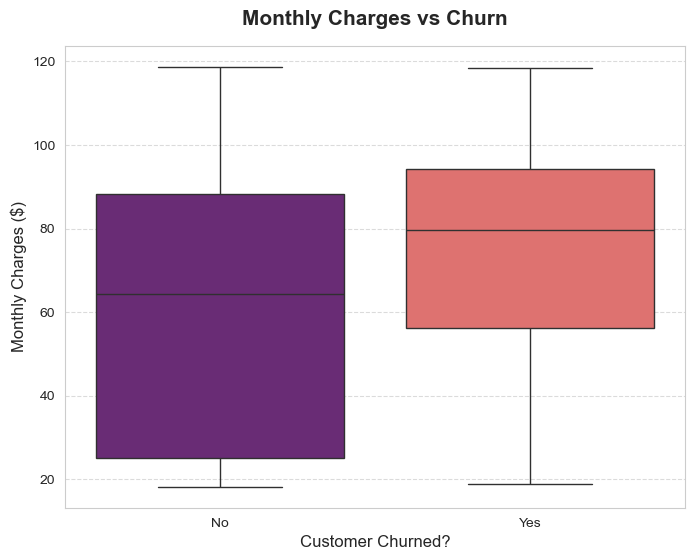

In [84]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='magma', legend=False)

plt.title('Monthly Charges vs Churn', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Customer Churned?', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

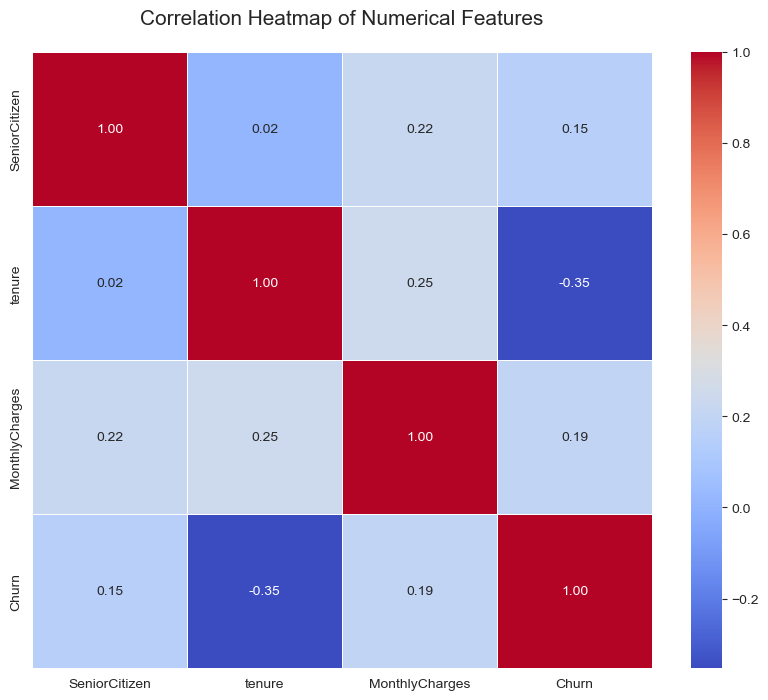

In [86]:
plt.figure(figsize=(10, 8))

# Convert Churn to numeric for correlation analysis
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select only numerical columns
numerical_cols = df_corr.select_dtypes(include=['number']).columns
corr_matrix = df_corr[numerical_cols].corr()

# Create Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=15, pad=20)
plt.show()